# SAVIA — Demo del DAO
## Sistema de Almacenamiento de Índices de Vegetación para Investigación Agronómica
### Proyecto Integrador Bases de Datos II · UNdeC 2026

Este notebook demuestra el funcionamiento del módulo `SaviaDAO` —
la capa de acceso a datos del sistema SAVIA.

El sistema soporta **múltiples clientes** (bodegas, productores, cooperativas)
sobre una base de datos compartida. Todas las consultas operativas reciben
un `cliente_id` que garantiza el aislamiento lógico entre organizaciones.

> **Prerequisito:** ejecutar `seed.py` antes de correr este notebook.

In [32]:
# =======================================================================
# IMPORTACIONES Y CONFIGURACIÓN INICIAL
# =======================================================================
from datetime import date
import matplotlib.pyplot as plt
from pymongo.errors import DuplicateKeyError

from dao import SaviaDAO
from db_models import Observacion

In [33]:
# -----------------------------------------------------------------------
# 1. Conexión a la Base de Datos
# -----------------------------------------------------------------------
print("=" * 60)
print("INICIALIZANDO CONEXIÓN")
dao = SaviaDAO()
print("✓ Conexión establecida con MongoDB (SaviaDAO)")

INICIALIZANDO CONEXIÓN
✓ Conexión establecida con MongoDB (SaviaDAO)


## MÓDULO 1: GESTIÓN DE CLIENTES Y USUARIOS

In [34]:
# -----------------------------------------------------------------------
# 1. Buscar clientes activos
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("1. CLIENTES ACTIVOS")
clientes = list(dao._clientes.find({"activo": True}))
for c in clientes:
    print(f"  {c['nombre']} — {c['tipo']} — plan {c['plan']}")


1. CLIENTES ACTIVOS
  Bodega El Cóndor — bodega — plan profesional
  Finca Los Sarmientos — productor_independiente — plan basico


In [35]:
# -----------------------------------------------------------------------
# 2. Obtener el cliente principal para las demos (Bodega El Cóndor)
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("2. SELECCIÓN DE CLIENTE PRINCIPAL")
condor = dao._clientes.find_one({"nombre": "Bodega El Cóndor"})
cliente_id = str(condor["_id"])
print(f"  [INFO] Usando cliente '{condor['nombre']}' (ID: {cliente_id}) para el resto del notebook.")


------------------------------------------------------------
2. SELECCIÓN DE CLIENTE PRINCIPAL
  [INFO] Usando cliente 'Bodega El Cóndor' (ID: 6a0789b567edb9d8cb22b48d) para el resto del notebook.


In [36]:
# -----------------------------------------------------------------------
# 3. Usuarios de un cliente
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("3. USUARIOS POR CLIENTE (BODEGA EL CÓNDOR)")
usuarios = dao.get_usuarios_por_cliente(cliente_id)
for u in usuarios:
    print(f"  {u['nombre']} — {u['rol']} — {u['email']}")


------------------------------------------------------------
3. USUARIOS POR CLIENTE (BODEGA EL CÓNDOR)
  Ana Gómez — admin — ana@elcondor.com
  Marcos Díaz — operador — marcos@elcondor.com


## MÓDULO 2: INVENTARIO DE PARCELAS

In [37]:
# -----------------------------------------------------------------------
# 4. Parcelas de un cliente filtradas por zona
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("4. PARCELAS DE BODEGA EL CÓNDOR EN NONOGASTA")
parcelas_nonogasta = dao.get_parcelas_por_zona(cliente_id, "Nonogasta")
for p in parcelas_nonogasta:
    print(f"  {p['nombre']} — {p['variedad']} — {p['superficie_ha']} ha")


4. PARCELAS DE BODEGA EL CÓNDOR EN NONOGASTA
  Finca El Peñón — Torrontés Riojano — 3.8 ha


In [38]:
# -----------------------------------------------------------------------
# 5. Parcelas filtradas por tipo de cultivo
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("5. PARCELAS POR CULTIVO (VID)")
parcelas_vid = dao.get_parcelas_por_cultivo(cliente_id, "vid")
print(f"  Total parcelas de vid: {len(parcelas_vid)}")
for p in parcelas_vid:
    print(f"  - {p['nombre']} ({p['zona']})")


------------------------------------------------------------
5. PARCELAS POR CULTIVO (VID)
  Total parcelas de vid: 2
  - Finca El Peñón (Nonogasta)
  - Viña Famatina (Famatina)


## MÓDULO 3: OBSERVACIONES SATELITALES Y SERIES TEMPORALES

In [39]:
# Seleccionamos una parcela específica para la demo de observaciones
penon = dao._parcelas.find_one({"nombre": "Finca El Peñón"})
parcela_id = str(penon["_id"])

# -----------------------------------------------------------------------
# 6. Registrar una nueva observación (con control de duplicados)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print(f"6. REGISTRAR OBSERVACIÓN — {penon['nombre']}")
try:
    obs_id = dao.registrar_observacion(
        Observacion(
            parcela_id=parcela_id,
            fecha=date(2024, 3, 18),
            ndvi=0.22,
            evi=0.16,
            ndwi=0.06,
            nubosidad_pct=2.1,
            fuente="Sentinel-2",
        )
    )
    print(f"  ✓ Observación registrada con id: {obs_id}")
except DuplicateKeyError:
    print("  [INFO] Observación ya existente para (parcela_id, 2024-03-18). Índice único activo.")


6. REGISTRAR OBSERVACIÓN — Finca El Peñón
  [INFO] Observación ya existente para (parcela_id, 2024-03-18). Índice único activo.


In [40]:
# -----------------------------------------------------------------------
# 7. Historial filtrado por rango de fechas (Verano)
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print(f"7. HISTORIAL SATELITAL FILTRADO (Dic 2023 – Feb 2024)")
obs_verano = dao.get_observaciones(
    parcela_id,
    desde=date(2023, 12, 1),
    hasta=date(2024, 2, 28)
)
print(f"  Observaciones encontradas en verano: {len(obs_verano)}")
for o in obs_verano:
    print(f"  {o['fecha']} | NDVI={o['ndvi']}")


------------------------------------------------------------
7. HISTORIAL SATELITAL FILTRADO (Dic 2023 – Feb 2024)
  Observaciones encontradas en verano: 6
  2023-12-04 | NDVI=0.71
  2023-12-19 | NDVI=0.69
  2024-01-03 | NDVI=0.65
  2024-01-18 | NDVI=0.58
  2024-02-02 | NDVI=0.47
  2024-02-17 | NDVI=0.38



------------------------------------------------------------
8. GENERANDO GRÁFICO DE ÍNDICES — Finca El Peñón


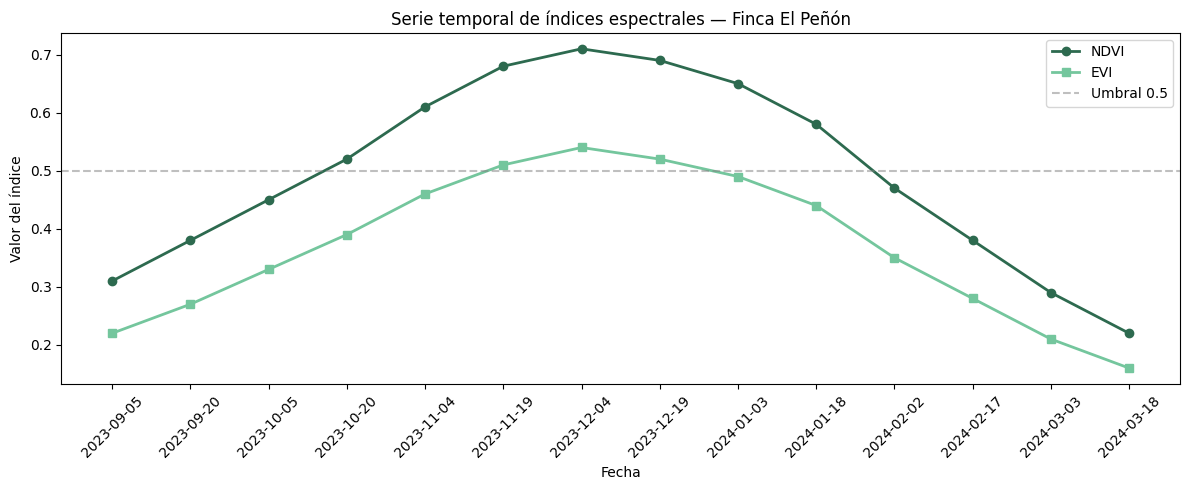

In [41]:
# -----------------------------------------------------------------------
# 8. Gráfico de serie temporal completo (matplotlib)
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print(f"8. GENERANDO GRÁFICO DE ÍNDICES — {penon['nombre']}")
observaciones_completas = dao.get_observaciones(parcela_id)

fechas = [o["fecha"] for o in observaciones_completas]
ndvi_vals = [o["ndvi"] for o in observaciones_completas]
evi_vals = [o["evi"] for o in observaciones_completas]

plt.figure(figsize=(12, 5))
plt.plot(fechas, ndvi_vals, marker="o", label="NDVI", color="#2d6a4f", linewidth=2)
plt.plot(fechas, evi_vals, marker="s", label="EVI", color="#74c69d", linewidth=2)
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
plt.title(f"Serie temporal de índices espectrales — {penon['nombre']}")
plt.xlabel("Fecha")
plt.ylabel("Valor del índice")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## MÓDULO 4: AGREGACIONES Y CAMPAÑAS

In [42]:
# -----------------------------------------------------------------------
# 9. Historial de campañas y cosechas
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print(f"9. CAMPAÑAS Y COSECHAS — {penon['nombre']}")
campanas = dao.get_campanas(parcela_id)
for c in campanas:
    print(f"  Temporada: {c['temporada']} | Cosecha: {c['fecha_cosecha']} | Rinde: {c['rendimiento_kg_ha']} kg/ha")
    if c.get("notas"):
        print(f"    Notas: {c['notas']}")


9. CAMPAÑAS Y COSECHAS — Finca El Peñón
  Temporada: 2023/2024 | Cosecha: 2024-02-28 | Rinde: 8400 kg/ha
    Notas: Sin eventos climáticos adversos. Riego controlado desde noviembre.


In [43]:
# -----------------------------------------------------------------------
# 10. NDVI promedio por zona (Agregación con $lookup)
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("10. NDVI PROMEDIO — NONOGASTA — TEMPORADA 2023/2024")
resultado_ndvi = dao.get_ndvi_promedio_por_zona(cliente_id, "Nonogasta", "2023/2024")
for r in resultado_ndvi:
    print(f"  Zona: {r['_id']} | NDVI promedio: {r['ndvi_promedio']:.3f} | Observaciones: {r['total_observaciones']}")


------------------------------------------------------------
10. NDVI PROMEDIO — NONOGASTA — TEMPORADA 2023/2024
  Zona: Nonogasta | NDVI promedio: 0.496 | Observaciones: 14


In [44]:
# -----------------------------------------------------------------------
# 11. Rendimiento promedio por zona
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("11. RENDIMIENTO PROMEDIO — LOS SARMIENTOS")
sarmientos = dao._clientes.find_one({"nombre": "Finca Los Sarmientos"})
rendimientos = dao.get_rendimiento_promedio_por_zona(str(sarmientos["_id"]), "Los Sarmientos")
for r in rendimientos:
    print(f"  Temporada: {r['_id']} | Rendimiento promedio: {r['rendimiento_promedio']} kg/ha | Parcelas: {r['parcelas']}")


------------------------------------------------------------
11. RENDIMIENTO PROMEDIO — LOS SARMIENTOS
  Temporada: 2023/2024 | Rendimiento promedio: 7200.0 kg/ha | Parcelas: 1


## MÓDULO 5: ALERTAS Y REPORTES

In [45]:
# -----------------------------------------------------------------------
# 12. Alertas activas de una parcela
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
sarmientos_norte = dao._parcelas.find_one({"nombre": "Finca Los Sarmientos Norte"})
print(f"12. ALERTAS ACTIVAS — {sarmientos_norte['nombre']}")
alertas = dao.get_alertas_activas_por_parcela(str(sarmientos_norte["_id"]))
if alertas:
    for a in alertas:
        print(f"  [{a['tipo']}] {a['fecha']} | {a['indice']}={a['valor_detectado']} (umbral={a['umbral']})")
else:
    print("  (Sin alertas activas)")


12. ALERTAS ACTIVAS — Finca Los Sarmientos Norte
  [estres_hidrico] 2024-01-19 | NDWI=0.16 (umbral=0.18)


In [46]:
# -----------------------------------------------------------------------
# 13. Reportes generales del cliente
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("13. REPORTES — BODEGA EL CÓNDOR")
reportes = dao.get_reportes_por_cliente(cliente_id)
for r in reportes:
    print(f"  [{r['tipo']}] {r['nombre']} (Estado: {r['estado']})")
    if r.get("resumen"):
        print(f"    Resumen: NDVI prom={r['resumen'].get('ndvi_promedio')} | obs={r['resumen'].get('observaciones_procesadas')}")


------------------------------------------------------------
13. REPORTES — BODEGA EL CÓNDOR
  [resumen_indices] Resumen NDVI — Temporada 2023/2024 (Estado: generado)
    Resumen: NDVI prom=0.54 | obs=26


## MÓDULO 6: CONSULTAS GEOESPACIALES NATIVAS (Índice 2dsphere)

In [47]:
LAT_CHILECITO = -29.01
LON_CHILECITO = -67.49

# -----------------------------------------------------------------------
# 14. Consulta $nearSphere (Por radio de distancia)
# -----------------------------------------------------------------------
print("\n" + "=" * 60)
print("14. BÚSQUEDA ESPACIAL ($nearSphere) — RADIO DESDE CHILECITO")
for radio in [15, 8, 3]:
    cercanas = dao.get_parcelas_cerca_de(cliente_id, LAT_CHILECITO, LON_CHILECITO, radio_km=radio)
    print(f"\n  Radio de {radio} km -> {len(cercanas)} parcelas encontradas:")
    for p in cercanas:
        print(f"    - {p['nombre']:30s} zona={p['zona']}")


14. BÚSQUEDA ESPACIAL ($nearSphere) — RADIO DESDE CHILECITO

  Radio de 15 km -> 2 parcelas encontradas:
    - Finca El Peñón                 zona=Nonogasta
    - Viña Famatina                  zona=Famatina

  Radio de 8 km -> 2 parcelas encontradas:
    - Finca El Peñón                 zona=Nonogasta
    - Viña Famatina                  zona=Famatina

  Radio de 3 km -> 1 parcelas encontradas:
    - Finca El Peñón                 zona=Nonogasta


In [48]:
# -----------------------------------------------------------------------
# 15. Consulta $geoWithin (Por Bounding Box / Polígono)
# -----------------------------------------------------------------------
print("\n" + "-" * 60)
print("15. BÚSQUEDA ESPACIAL ($geoWithin) — BOUNDING BOX")

# Área amplia
parcelas_en_area = dao.get_parcelas_en_bbox(
    cliente_id, sw_lat=-29.05, sw_lon=-67.53, ne_lat=-28.98, ne_lon=-67.45
)
print(f"\n  En área amplia: {len(parcelas_en_area)} parcelas")

# Área sector norte
parcelas_norte = dao.get_parcelas_en_bbox(
    cliente_id, sw_lat=-29.00, sw_lon=-67.53, ne_lat=-28.98, ne_lon=-67.45
)
print(f"  En sector norte (Famatina): {len(parcelas_norte)} parcelas")


------------------------------------------------------------
15. BÚSQUEDA ESPACIAL ($geoWithin) — BOUNDING BOX

  En área amplia: 2 parcelas
  En sector norte (Famatina): 1 parcelas


In [49]:
# =======================================================================
# CIERRE
# =======================================================================
print("\n" + "=" * 60)
dao.cerrar()
print("✓ Conexión cerrada. Consultas completadas.")


✓ Conexión cerrada. Consultas completadas.
